# Ejemplo de análisis sesgo-varianza usando validación cruzada 

## Conjunto de datos Iris y modelo de regresión por vecinos más cercanos

### Exploración del conjunto de datos

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [107]:
# Para facilitar la interpretación del target
# mapeamos los valores enteros en sus correspondientes especies
iris_copy = iris.frame
iris_copy.loc[:,'species'] = iris.frame['target'].map(lambda x: iris.target_names[x])
iris_copy.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Las partes de una flor del género Iris. [US Forest service](https://www.fs.usda.gov/wildflowers/beauty/iris/flower.shtml) ![U.S. Forest Service](https://www.fs.usda.gov/wildflowers/beauty/iris/images/flower/blueflagiris_flower.jpg)

In [108]:
iris_copy.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [109]:
iris_copy.select_dtypes(include='float64').describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [110]:
iris_copy['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

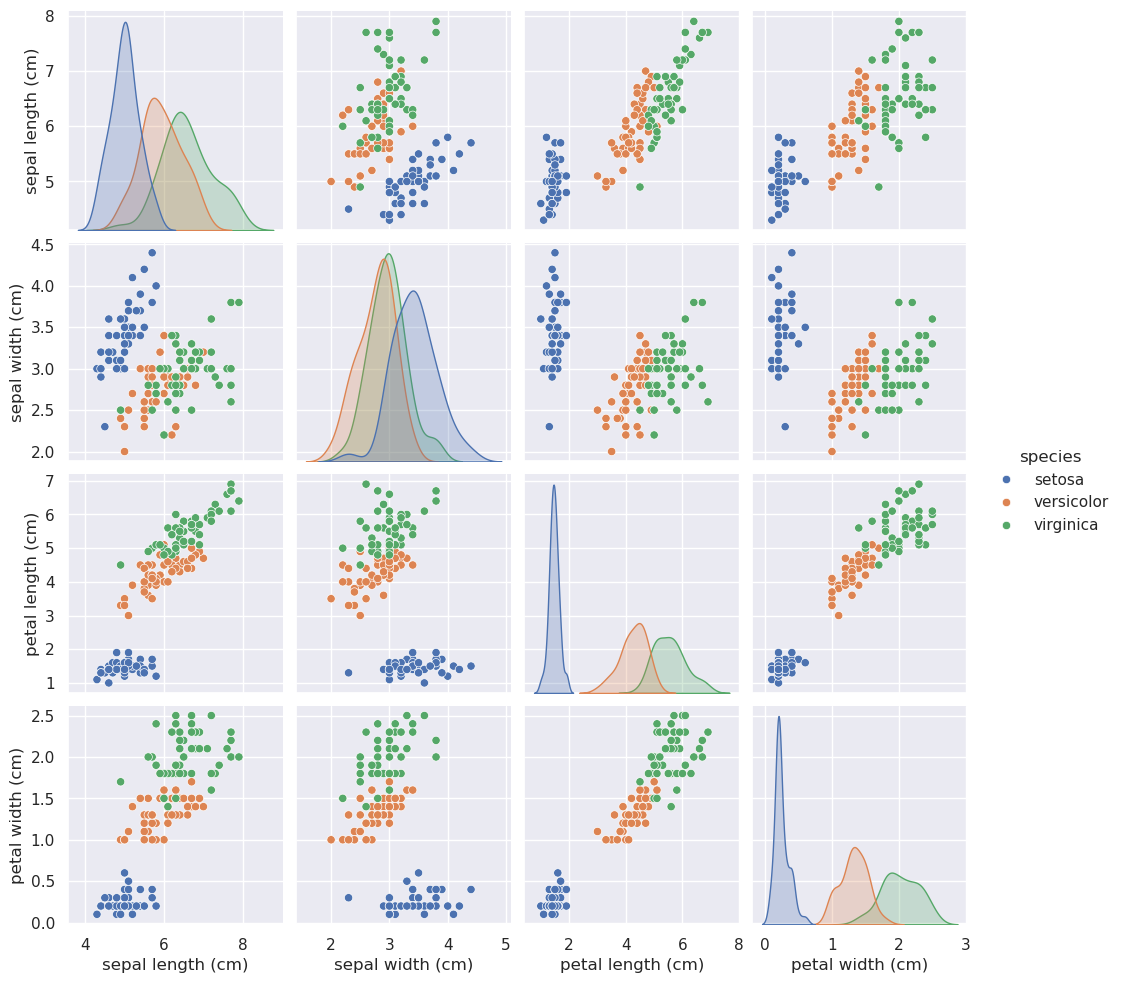

In [111]:
sns.pairplot(iris_copy.select_dtypes(include=['float64','object']), hue='species')

## Definición del modelo de regresión por vecinos más cercanos


### Predicción de la variable 'petal length (cm)' y evaluación usando train_test_split


In [112]:
from sklearn.model_selection import train_test_split

iris_numeric = ['sepal length (cm)', 'sepal width (cm)']
iris_cat = ['species']

X = iris_copy.loc[:, iris_numeric  + iris_cat].drop_duplicates()
y = iris_copy.loc[X.index, 'petal length (cm)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

### Construcción de la transformación por columnas y del pipeline

In [113]:
preproc = ColumnTransformer(
    [('scaler', StandardScaler(), iris_numeric),
     ('one-hot',OneHotEncoder(), iris_cat)
    ])

pipe = Pipeline([('preproc', preproc), ('knn', KNeighborsRegressor())]) 

### Balance sesgo-varianza en función del K

In [114]:
from sklearn.metrics import root_mean_squared_error

k_all = np.arange(1, 21, 2)
r2_train = np.array([])
r2_test = np.array([])
rmse_train = np.array([])
rmse_test = np.array([])
for k in k_all:
    pipe.set_params(knn__n_neighbors=k)
    pipe.fit(X_train, y_train)
    r2_train = np.append(r2_train, [pipe.score(X_train, y_train)])
    r2_test = np.append(r2_test, [pipe.score(X_test, y_test)])
    rmse_train = np.append(rmse_train, [root_mean_squared_error(pipe.predict(X_train), y_train)])
    rmse_test = np.append(rmse_test, [root_mean_squared_error(pipe.predict(X_test), y_test)])


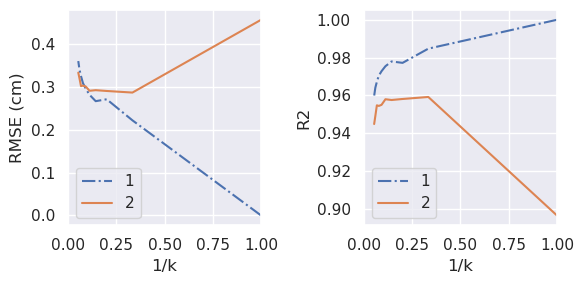

In [115]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows = 1,ncols = 2, figsize = (6,3), dpi=100)
ax[0].plot(1/k_all, rmse_train, label='1', linestyle='-.')
ax[0].plot(1/k_all, rmse_test, label='2', linestyle='-')
ax[0].set_xlim([0,np.max(1/k_all)])
ax[0].set_xlabel("1/k")
ax[0].set_ylabel("RMSE (cm)")
ax[0].legend(loc='lower left')

ax[1].plot(1/k_all, r2_train, label='1', linestyle='-.')
ax[1].plot(1/k_all, r2_test, label='2', linestyle='-')
ax[1].set_xlim([0,np.max(1/k_all)])
ax[1].set_xlabel("1/k")
ax[1].set_ylabel("R2")
ax[1].legend(loc='lower left')
fig.tight_layout()

### Predicción de la variable 'petal length (cm)' y evaluación usando validación cruzada

**¡ATENCIÓN!**: *No se realiza la evaluación de desempeño final para facilitar la comparación con el caso anterior. Sin embargo, toda evaluación comienza con la partición en datos de entrenamiento y prueba que se reservan sin leer hasta el final, luego de la eleción de los hiperparámetros. Se deja como ejercicio.*.

![Gumball-angry](gumball-gumball-angry.gif)

A continuación se muestra una visualización del comportamiento de validación cruzada. Debemos tener en cuenta que `KFold` no se ve afectado por la presencia de clases o grupos:

![Representación de la separación en 4 compartientos de datos](https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_006.png)

Cada compartimeinto está constituido por dos arreglos: el primero está relacionado con el conjunto de entrenamiento y el segundo con el conjunto de validación. 

Sin embargo, algunos conjuntos de datos pueden sufrir un gran desequilibrio en la proporción en la que incorporan los diferntes objetos de una clase. En tales casos, se recomienda utilizar el muestreo estratificado implementado en `StratifiedKFold` y `StratifiedShuffleSplit` para garantizar que las frecuencias relativas con las que se presentan los diferentes objetos se conserven aproximadamente en cada compartimeinto de validación.

![Representación de la separación en 4 compartimientos de datos que respectan la frecuencia relativa con la que se presentan los objetos de una clase](https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_009.png)

`StratifiedKFold` es una variación de k-fold que devuelve carpetas (folds) estratificados. Cada conjunto contiene aproximadamente el mismo porcentaje de muestras de cada clase objetivo que el conjunto completo. Podemos ver que `StratifiedKFold` conserva las proporciones de clases tanto en el conjunto de datos de entrenamiento como en el de validación.

In [116]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import make_scorer

from sklearn.model_selection import StratifiedKFold, KFold

En este caso particular, también le pasamos a `cross_validate` la estrategia de partición en los difrentes compartimientos ya que, por default emplea `k-fold`. Sin embargo, dado que debemos mantener la relación de las categorías 'setosa', 'versicolor' y 'virginica', se necesitamos una separación estratificada que implementamos a través de la clase `CustomStratifiedKFold`.

In [117]:
class CustomStratifiedKFold:
    def __init__(self, n_splits=5, random_state=42):
        self.n_splits = n_splits
        self.random_state = random_state
        self.skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

    def split(self, X, y):
        for train_index, test_index in self.skf.split(X, X['species']):
            yield train_index, test_index

    def get_n_splits(self, X, y, groups=None):
        return self.n_splits

kfold=5
# Instantiate custom generator
custom_cv = CustomStratifiedKFold(n_splits=kfold)


rmse_scorer = make_scorer(root_mean_squared_error)

k_all = np.arange(1, 21, 2)
r2_val = np.empty((0,kfold))
r2_train = np.empty((0,kfold))
rmse_val = np.empty((0, kfold))
rmse_train = np.empty((0, kfold))
for k in k_all:
    pipe.set_params(knn__n_neighbors=k)
    cv_results = cross_validate(pipe, X_train, y=y_train,
                                cv=custom_cv.split(X_train, y_train),
                                scoring={'r2': 'r2', 'rmse': rmse_scorer},
                                return_train_score=True)
    # Descomentar alternadamente para ver el error que provoca no tener en cuenta las proporciones de las diferentes clases
    # cv_results = cross_validate(pipe, X, y=y, cv=kfold, scoring={'r2': 'r2', 'rmse': rmse_scorer}, return_train_score=True)
    # cv_results = cross_validate(pipe, X, y=y, cv=custom_cv.split(X, y), scoring={'r2': 'r2', 'rmse': rmse_scorer}, return_train_score=True)
    r2_val = np.append(r2_val, [cv_results['test_r2']], axis=0)
    r2_train = np.append(r2_train, [cv_results['train_r2']], axis=0)
    rmse_val = np.append(rmse_val, [cv_results['test_rmse']], axis=0)
    rmse_train = np.append(rmse_train, [cv_results['train_rmse']], axis=0)

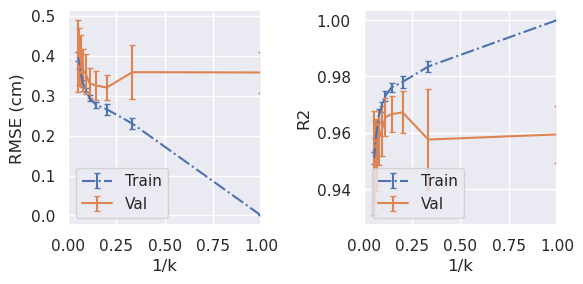

In [118]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows = 1,ncols = 2, figsize = (6,3), dpi=100)

ax[0].errorbar(1/k_all, rmse_train.mean(axis=1), yerr=rmse_train.std(axis=1), label='Train', linestyle='-.', capsize=2)
ax[0].errorbar(1/k_all, rmse_val.mean(axis=1), yerr=rmse_val.std(axis=1), label='Val', linestyle='-', capsize=2)
ax[0].set_xlim([0,np.max(1/k_all)])
# ax[0].set_ylim([0,0.45])
ax[0].set_xlabel("1/k")
ax[0].set_ylabel("RMSE (cm)")
ax[0].legend(loc='lower left')


ax[1].errorbar(1/k_all, r2_train.mean(axis=1), yerr=r2_train.std(axis=1), label='Train', linestyle='-.', capsize=2)
ax[1].errorbar(1/k_all, r2_val.mean(axis=1), yerr=r2_val.std(axis=1), label='Val', linestyle='-', capsize=2)
ax[1].set_xlim([0,np.max(1/k_all)])
# ax[1].set_ylim([0.89,1.0])
ax[1].set_xlabel("1/k")
ax[1].set_ylabel("R2")
ax[1].legend(loc='lower left')
fig.tight_layout()

## Búsqueda de mejores parámetros sobre una grilla de valores 

Una vez que automatizamos la cadena de procesamiento, podemos ejecutarla para diferentes conjuntos de parámteros. En este caso, vamos a variar el número de vecinos. La intención es encontrar el 'k' que produce el mejor puntaje en el proceso de validación cruzada. `GridSearchCV` repite la ejecución de la misma cadena de procesamiento para todos los valores que se le pasen como argumento en formato diccionario. Como la función busca el puntaje más alto, en el caso de que se evalúe el acuerdo mediante el RMSE, se debe pasar su inverso `neg_root_mean_squared_error`. 

En este caso particular, también le pasamos a `GridSearchCV` la estrategia de partición en los difrentes compartimientos ya que, por default emplea `k-fold`. Sin embargo, dado que debemos tener en cuenta las categorías, necesitamos una separación estratificada que implementamos a través de la función `custom_cv_folds()`.

In [119]:
from sklearn.model_selection import GridSearchCV

parameters = {'knn__n_neighbors': np.arange(1, 21, 2).tolist(),
              'knn__weights': ['uniform', 'distance']}

grid = GridSearchCV(pipe, parameters,
                    scoring='neg_root_mean_squared_error',
                    cv=custom_cv.split(X_train, y_train), return_train_score=True)

# from sklearn.model_selection import RandomizedSearchCV
# grid = RandomizedSearchCV(pipe, parameters, 
#                           scoring='neg_root_mean_squared_error',
#                           cv=custom_cv.split(X_train, y_train), return_train_score=True, random_state=0)

# When the Pipeline is printed out in a jupyter notebook an HTML
# representation of the estimator is displayed:
grid

GridSearchCV(cv=<generator object CustomStratifiedKFold.split at 0x7f447f2448b0>,
             estimator=Pipeline(steps=[('preproc',
                                        ColumnTransformer(transformers=[('scaler',
                                                                         StandardScaler(),
                                                                         ['sepal '
                                                                          'length '
                                                                          '(cm)',
                                                                          'sepal '
                                                                          'width '
                                                                          '(cm)']),
                                                                        ('one-hot',
                                                                         OneHotEncoder(),
                                                                         ['species'])])),
                                       ('knn',
                                        KNeighborsRegressor(n_neighbors=np.int64(19)))]),
             param_grid={'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17,
                                              19],
                         'knn__weights': ['uniform', 'distance']},
             return_train_score=True, scoring='neg_root_mean_squared_error')

![Bear's tower](Bearstack.png)

Luego de la búsqueda imprimimos el conjunto de mejores parámetros. 

In [120]:
# Calling ‘fit’ triggers the cross-validated search for
# the best hyper-parameters combination:             
grid.fit(X_train, y_train)

print("Best params:")
print(grid.best_params_)

# The internal cross-validation scores obtained by those parameters is:

print(f"Internal CV score: {grid.best_score_:.3f}")

Best params:
{'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Internal CV score: -0.315


En general, los resultados de cada iteración se presentan en la variable grid.results. 

In [121]:
grid_results = pd.DataFrame(grid.cv_results_)
grid_results[4:10]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,param_knn__weights,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
4,0.005728,0.000374,0.004106,0.000216,5,uniform,"{'knn__n_neighbors': 5, 'knn__weights': 'unifo...",-0.332036,-0.354119,-0.262336,...,-0.320148,0.030834,3,-0.266008,-0.262128,-0.278842,-0.241221,-0.280079,-0.265656,0.014082
5,0.005500,0.000018,0.004003,0.000005,5,distance,"{'knn__n_neighbors': 5, 'knn__weights': 'dista...",-0.299638,-0.358483,-0.264826,...,-0.316461,0.032990,2,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000
6,0.005493,0.000008,0.003972,0.000008,7,uniform,"{'knn__n_neighbors': 7, 'knn__weights': 'unifo...",-0.364269,-0.358910,-0.275551,...,-0.325283,0.036707,5,-0.271959,-0.266959,-0.284176,-0.287385,-0.275935,-0.277283,0.007567
7,0.005569,0.000198,0.004011,0.000016,7,distance,"{'knn__n_neighbors': 7, 'knn__weights': 'dista...",-0.324607,-0.351456,-0.265962,...,-0.315108,0.031304,1,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000
8,0.005468,0.000009,0.003972,0.000007,9,uniform,"{'knn__n_neighbors': 9, 'knn__weights': 'unifo...",-0.374362,-0.372910,-0.295167,...,-0.330743,0.037991,6,-0.290088,-0.281990,-0.300439,-0.303053,-0.293858,-0.293886,0.007522
9,0.005602,0.000096,0.004135,0.000180,9,distance,"{'knn__n_neighbors': 9, 'knn__weights': 'dista...",-0.336803,-0.364612,-0.285928,...,-0.321564,0.029441,4,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000


In [122]:
# We can also introspect the top grid search results as a pandas dataframe:

grid_results = pd.DataFrame(grid.cv_results_)
print('CV Results Column Names: ', grid_results.columns)

CV Results Column Names:  Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_knn__n_neighbors', 'param_knn__weights', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')


Asimismo, tomamos los resultados de la variable `grid.results` para mostrar los proemdios de los score de los datos de entreamiento y los datos de validación. Renombramos las columnas para mayor facilidad de interpretación. Y multiplicamos por (-1) para cambiar el signo por el scoring negativo...

In [123]:
grid_results.rename(columns={'param_knn__n_neighbors': 'n_neighbors'},
                    inplace=True)
grid_results.rename(columns={'param_knn__weights': 'weights'},
                    inplace=True)
grid_results[['mean_train_score',
              'mean_test_score']] = grid_results[['mean_train_score',
                                'mean_test_score']].apply(lambda x: x * (-1))

/tmp/ipykernel_4470/3629194913.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_4470/3629194913.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


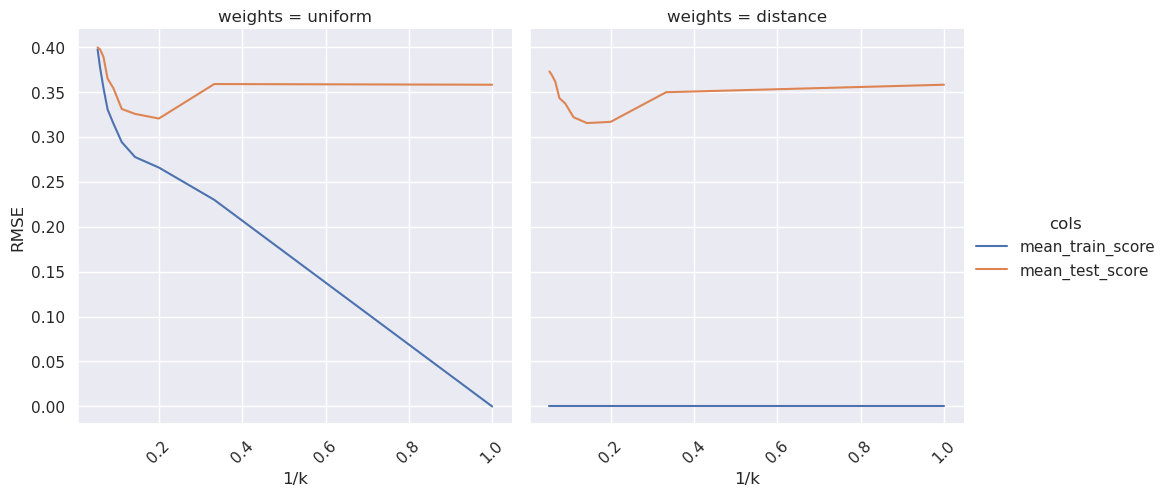

In [124]:

import seaborn as sns

grid_results.loc[:,'1/k'] = np.round(1 / grid_results['n_neighbors'],3)
dfm = grid_results[['1/k', 'mean_train_score',
                    'mean_test_score', 'weights']].melt(['1/k', 'weights'],
                                             var_name='cols', value_name='RMSE')

# Apply the default theme
sns.set_theme()

g = sns.relplot(
    kind='line',
    markers=['x', 'o'],
    data=dfm,
    x='1/k', y='RMSE', hue='cols', col='weights'
)
for ax in g.axes.flat:
# rotate the labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


**Ejercicio**: Completar la evaluación de desempeño calculando el RMSE para el conjunto de datos de prueba que había sido reservado. ¿Cómo compara con el valor del RMSE promedio en validación cruzada?